In [1]:
# System aur deep learning libraries import kar rahe hain
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Data analysis aur visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Keras ke andar built-in MNIST dataset load kar rahe hain
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Shapes check karte hain
print("Training Images shape:", X_train.shape)   # Output: (60000, 28, 28)
print("Training Labels shape:", y_train.shape)   # Output: (60000,)
print("Test Images shape:", X_test.shape)       # Output: (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images shape: (60000, 28, 28)
Training Labels shape: (60000,)
Test Images shape: (10000, 28, 28)


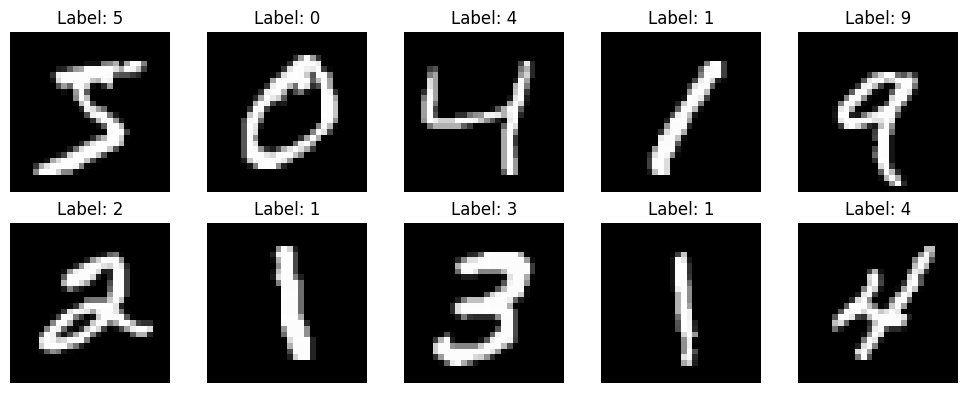

In [3]:
# Pehli 10 images display karte hain
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Pixel values ko 0 to 1 scaling/normalization kar rahe hain
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel minimum value:", X_train.min()) # Output: 0.0
print("Pixel maximum value:", X_train.max()) # Output: 1.0

Pixel minimum value: 0.0
Pixel maximum value: 1.0


In [5]:
# Sequential Neural Network model create kar rahe hain
model = keras.Sequential([
    # 28x28 2D array ko 784 1D array me convert kar raha hai
    layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer 1: 128 Neurons with ReLU activation
    layers.Dense(128, activation='relu'),

    # Hidden Layer 2: 64 Neurons with ReLU activation
    layers.Dense(64, activation='relu'),

    # Output Layer: 10 Neurons (0 se 9 tak ke digits ke probabilities ke liye)
    layers.Dense(10, activation='softmax')
])

# Model ka summary print karte hain
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 10 Epochs tak training chalegi
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9180 - loss: 0.2867 - val_accuracy: 0.9662 - val_loss: 0.1170
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9644 - loss: 0.1187 - val_accuracy: 0.9720 - val_loss: 0.0980
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9757 - loss: 0.0800 - val_accuracy: 0.9725 - val_loss: 0.0883
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9812 - loss: 0.0615 - val_accuracy: 0.9778 - val_loss: 0.0773
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9842 - loss: 0.0484 - val_accuracy: 0.9758 - val_loss: 0.0891
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9877 - loss: 0.0388 - val_accuracy: 0.9778 - val_loss: 0.0780
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9891 - loss: 0.0326 - val_accuracy: 0.9752 - val_loss: 0.0942
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9919 - loss: 0.0256 - val_accuracy: 0.

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9794 - loss: 0.0769

Final Test Accuracy: 97.94%


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


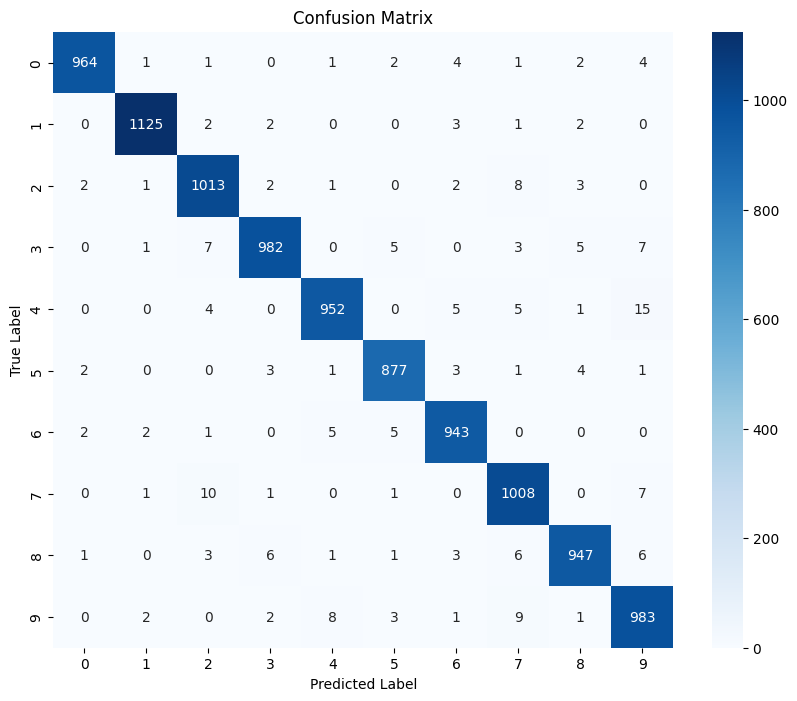

In [10]:
# 1. Test set par predictions generate karo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix banao
conf_matrix = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)

# 3. Heatmap visualization plot karo
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

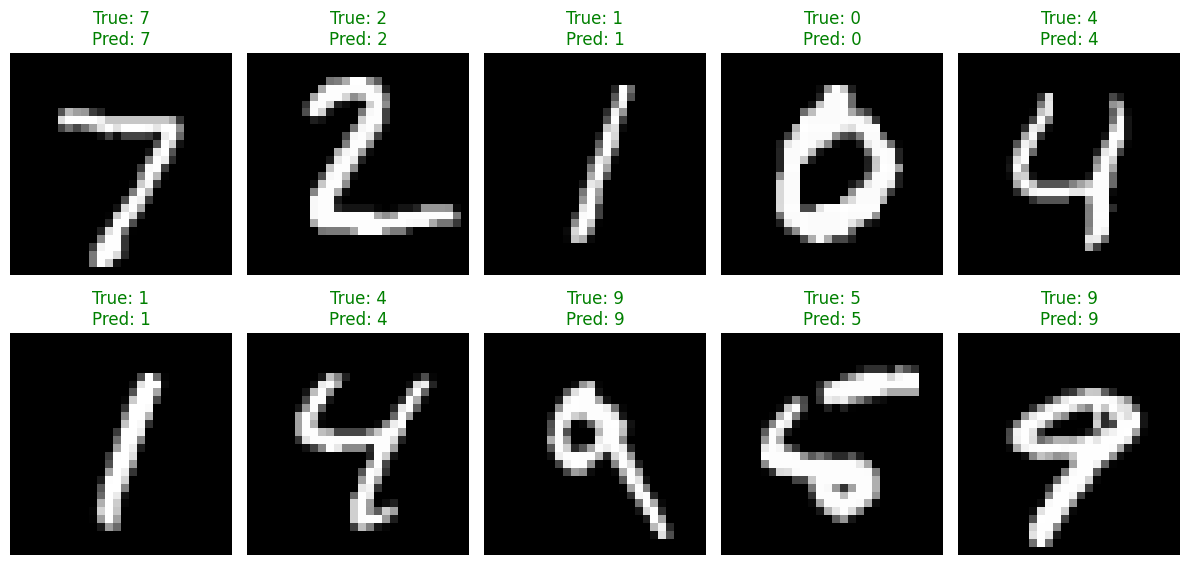

In [11]:
# Random 10 test images aur unki predictions dikhao
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()